# Assignment 2

#1.1 Polynomial regression and coefficient analysis

Model:
$ y = w_0 + w_1 x + w_2 x^2 + \epsilon,\ \epsilon\sim\mathcal N(0,s).$

**Tasks**
1. Implement `poly_model` with sites `w0,w1,w2,s_eps`.
2. Train with (i) `AutoDiagonalNormal` and (ii) `AutoMultivariateNormal`. Plot both loss curves.
3. Plot predictive median + 90% band for both guides.
4. Posterior samples: compute Corr(w1,w2) for both guides and explain why correlation occurs.
5. Plot joint posterior (w1,w2) for both guides.
6. **Beyond ELBO:** record coefficient trajectories over training (posterior means of w0,w1,w2,s_eps at checkpoints) and plot them.


In [1]:
#set up
import jax
import jax.numpy as jnp
import jax.random as random
import numpy as np
import matplotlib.pyplot as plt
import optax

#!pip install numpyro
import numpyro
import numpyro.distributions as dist
from numpyro.distributions import constraints
from numpyro.infer import SVI, Trace_ELBO, Predictive
from numpyro.infer.autoguide import AutoDiagonalNormal, AutoMultivariateNormal, AutoIAFNormal

from jax import jit
from jax.scipy.special import logsumexp

numpyro.set_platform('cpu')
key = random.PRNGKey(1234)
print('JAX devices:', jax.devices())



JAX devices: [CpuDevice(id=0)]


## 1.1a Setup and data

In [2]:
def poly_model(x, y=None):
    w0 = numpyro.sample("w0", dist.Normal(0.0, 10.0))
    w1 = numpyro.sample("w1", dist.Normal(0.0, 10.0))
    w2 = numpyro.sample("w2", dist.Normal(0.0, 10.0))
    s_eps = numpyro.sample("s_eps", dist.HalfCauchy(10.0))
    mu = w0 + w1 * x + w2 * x**2
    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("y", dist.Normal(mu, s_eps), obs=y)

def train_val_split(x, y, ratio=0.8):
    N = x.shape[0]
    n_train = int(N * ratio)
    return (x[:n_train], y[:n_train]), (x[n_train:], y[n_train:])

def plot_data(x, y, title='data'):
    plt.figure(figsize=(6,4))
    plt.scatter(np.array(x), np.array(y), s=15, color='k', alpha=0.7)
    plt.title(title)
    plt.xlabel('x')
    plt.ylabel('y')
    plt.show()

def run_svi(model, guide, key, *args, lr=1e-2, steps=2000, particles=1):
    svi = SVI(model, guide, optax.adam(lr), Trace_ELBO(num_particles=particles))
    state = svi.init(key, *args)
    jit_update = jit(svi.update)
    losses = []
    for t in range(steps):
        state, loss = jit_update(state, *args)
        losses.append(float(loss))
    return svi, state, jnp.array(losses)

def sample_posterior(model, svi, state, key, x, num_samples=2000, sites=None):
    params = svi.get_params(state)
    predictive = Predictive(model, guide=svi.guide, params=params,
                            num_samples=num_samples, return_sites=sites)
    return predictive(key, x, y=None)

def plot_loss(losses, title='SVI loss'):
    plt.figure(figsize=(6,4))
    plt.plot(np.array(losses))
    plt.title(title)
    plt.xlabel('step')
    plt.ylabel('loss (negative ELBO)')
    plt.yscale('log')
    plt.show()

def summary_stats(samples_1d):
    # mean, std, 95% CI
    mean = float(jnp.mean(samples_1d))
    std = float(jnp.std(samples_1d))
    lo, hi = jnp.quantile(samples_1d, jnp.array([0.025, 0.975]))
    return mean, std, float(lo), float(hi)

def corrcoef(a, b):
    a = jnp.asarray(a)
    b = jnp.asarray(b)
    a = a - jnp.mean(a)
    b = b - jnp.mean(b)
    return float(jnp.sum(a*b) / (jnp.sqrt(jnp.sum(a*a)) * jnp.sqrt(jnp.sum(b*b)) + 1e-12))

def predictive_band_from_mu(mu_samples, q=(0.05, 0.5, 0.95)):
    qs = jnp.quantile(mu_samples, jnp.array(q), axis=0)
    return qs[0], qs[1], qs[2]

def coverage_from_mu(mu_samples, y_obs, alpha=0.10):
    # Empirical coverage of (1-alpha) interval computed from mu samples
    lo, hi = jnp.quantile(mu_samples, jnp.array([alpha/2, 1-alpha/2]), axis=0)
    covered = (y_obs >= lo) & (y_obs <= hi)
    return float(jnp.mean(covered))

def spearman_corr(x, y):
    # Spearman correlation via rank transform
    x = np.asarray(x)
    y = np.asarray(y)
    rx = x.argsort().argsort().astype(float)
    ry = y.argsort().argsort().astype(float)
    rx = (rx - rx.mean()) / (rx.std() + 1e-12)
    ry = (ry - ry.mean()) / (ry.std() + 1e-12)
    return float((rx*ry).mean())

def track_posterior_means(model, guide, key, x_tr, y_tr, sites, lr=1e-2, steps=2000, every=100, S=200):
    # Train SVI and periodically record posterior means of given sites
    svi = SVI(model, guide, optax.adam(lr), Trace_ELBO())
    state = svi.init(key, x_tr, y_tr)
    jit_update = jit(svi.update)

    t_list = []
    losses = []
    means = {s: [] for s in sites}

    for t in range(steps):
        state, loss = jit_update(state, x_tr, y_tr)
        losses.append(float(loss))
        if (t % every) == 0 or t == steps-1:
            params = svi.get_params(state)
            pred = Predictive(model, guide=svi.guide, params=params, num_samples=S, return_sites=sites)
            samps = pred(random.fold_in(key, t), x_tr)
            for s in sites:
                means[s].append(float(jnp.mean(samps[s])))
            t_list.append(t)

    return svi, state, np.array(losses), np.array(t_list), {k: np.array(v) for k,v in means.items()}




## 1.1b Train and plot loss curves



In [3]:
def make_poly_data(key, N=100, w0_true=1.5, w1_true=-2.0, w2_true=0.8, s_true=1.5):
    """
    Generate noisy quadratic data:
    y = w0 + w1*x + w2*x^2 + noise
    """
    key, k1, k2 = random.split(key, 3)
    x = dist.Normal(0.0, 2.0).sample(k1, sample_shape=(N,))
    x = jnp.sort(x)
    y = w0_true + w1_true * x + w2_true * x**2 + dist.Normal(0.0, s_true).sample(k2, sample_shape=(N,))
    return key, x, y, (w0_true, w1_true, w2_true, s_true)

# Generate training data
key, x_train, y_train, true_params = make_poly_data(key, N=100)

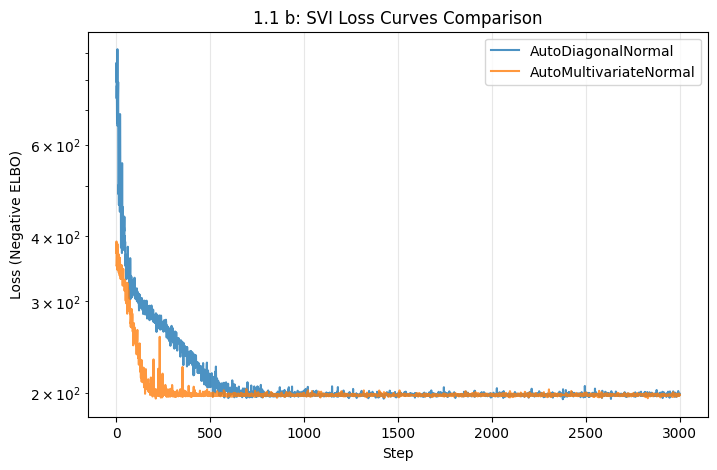

In [4]:
guide_diag = AutoDiagonalNormal(poly_model)
guide_mvn = AutoMultivariateNormal(poly_model)

# Split RNG keys for the two SVI runs
key, key_diag, key_mvn = random.split(key, 3)

# Run SVI training
svi_diag, state_diag, losses_diag = run_svi(
    poly_model, guide_diag, key_diag, x_train, y_train, lr=0.01, steps=3000
)

svi_mvn, state_mvn, losses_mvn = run_svi(
    poly_model, guide_mvn, key_mvn, x_train, y_train, lr=0.01, steps=3000
)

# Plot loss curves (negative ELBO) for comparison
plt.figure(figsize=(8, 5))
plt.plot(losses_diag, label='AutoDiagonalNormal', alpha=0.8)
plt.plot(losses_mvn, label='AutoMultivariateNormal', alpha=0.8)
plt.title('1.1 b: SVI Loss Curves Comparison')
plt.xlabel('Step')
plt.ylabel('Loss (Negative ELBO)')
plt.yscale('log')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


## 1.1c Plot predictive bands for both guides on the same test grid.


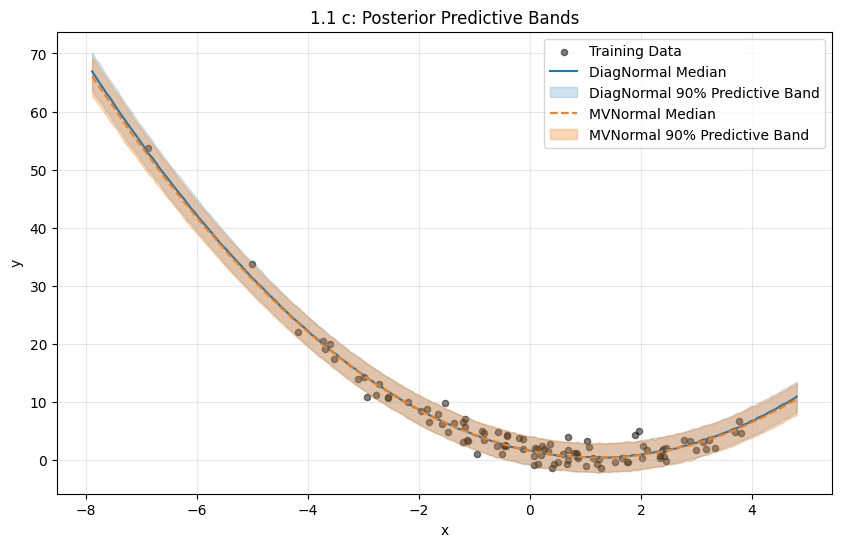

In [5]:
x_test = jnp.linspace(x_train.min() - 1.0, x_train.max() + 1.0, 200)

# Draw posterior predictive samples of the observed variable y
key, key_pred_diag, key_pred_mvn = random.split(key, 3)
samples_diag = sample_posterior(poly_model, svi_diag, state_diag, key_pred_diag, x_test, num_samples=2000, sites=["y"])
samples_mvn  = sample_posterior(poly_model, svi_mvn, state_mvn, key_pred_mvn, x_test, num_samples=2000, sites=["y"])

y_pred_diag = samples_diag["y"]
y_pred_mvn  = samples_mvn["y"]

# Compute predictive quantile bands (5%, 50%, 95%)
lo_diag, med_diag, hi_diag = predictive_band_from_mu(y_pred_diag)
lo_mvn,  med_mvn,  hi_mvn  = predictive_band_from_mu(y_pred_mvn)

# Visualize
plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train, color="black", s=20, alpha=0.5, label="Training Data")
plt.plot(x_test, med_diag, color="C0", label="DiagNormal Median")
plt.fill_between(x_test, lo_diag, hi_diag, color="C0", alpha=0.2, label="DiagNormal 90% Predictive Band")
plt.plot(x_test, med_mvn, color="C1", linestyle="--", label="MVNormal Median")
plt.fill_between(x_test, lo_mvn, hi_mvn, color="C1", alpha=0.3, label="MVNormal 90% Predictive Band")
plt.title("1.1 c: Posterior Predictive Bands")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 1.1d Draw posterior samples and compute Corr for both guides

In [6]:
# Sample posterior draws of parameters w1 and w2
key, k_diag, k_mvn = random.split(key, 3)
samples_diag_params = sample_posterior(
    poly_model, svi_diag, state_diag, k_diag, x_train, num_samples=2000, sites=["w1", "w2"]
)
samples_mvn_params = sample_posterior(
    poly_model, svi_mvn, state_mvn, k_mvn, x_train, num_samples=2000, sites=["w1", "w2"]
)

# Extract parameter samples
w1_diag, w2_diag = samples_diag_params["w1"], samples_diag_params["w2"]
w1_mvn,  w2_mvn  = samples_mvn_params["w1"],  samples_mvn_params["w2"]

# Compute correlation
corr_diag = corrcoef(w1_diag, w2_diag)
corr_mvn  = corrcoef(w1_mvn, w2_mvn)

print(f"Corr(w1, w2) for AutoDiagonalNormal:     {corr_diag:.4f}")
print(f"Corr(w1, w2) for AutoMultivariateNormal: {corr_mvn:.4f}")

Corr(w1, w2) for AutoDiagonalNormal:     -0.0107
Corr(w1, w2) for AutoMultivariateNormal: 0.2674


## 1.1e Joint posterior

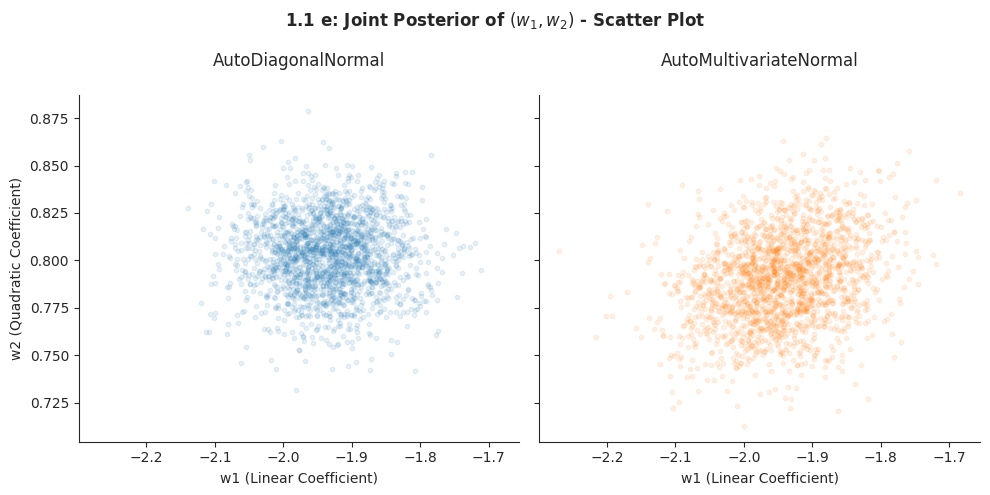

In [7]:
# 1.1 e: Plot the joint posterior of (w1, w2) (Scatter Plot)
import seaborn as sns

sns.set_style("ticks")
fig, axes = plt.subplots(1, 2, figsize=(10, 5), sharex=True, sharey=True)

# Left
axes[0].scatter(w1_diag, w2_diag, alpha=0.1, s=10, color="tab:blue")
axes[0].set_title("AutoDiagonalNormal\n")
axes[0].set_xlabel("w1 (Linear Coefficient)")
axes[0].set_ylabel("w2 (Quadratic Coefficient)")

# Right
axes[1].scatter(w1_mvn, w2_mvn, alpha=0.1, s=10, color="tab:orange")
axes[1].set_title("AutoMultivariateNormal\n")
axes[1].set_xlabel("w1 (Linear Coefficient)")

plt.suptitle("1.1 e: Joint Posterior of $(w_1, w_2)$ - Scatter Plot", fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()

## 1.1f Coefficient trajectory plot

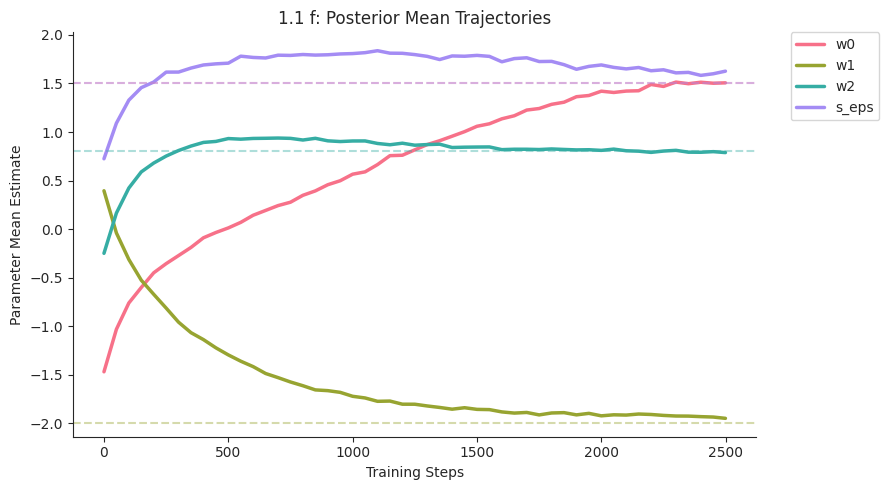

In [8]:
# 1.1 f: Coefficient trajectory plot
# Re-initialize an MVN guide for tracking
guide_mvn_track = AutoMultivariateNormal(poly_model)
sites_to_track = ["w0", "w1", "w2", "s_eps"]

svi_t, state_t, losses_t, t_list, means_dict = track_posterior_means(
    poly_model, guide_mvn_track, key, x_train, y_train,
    sites=sites_to_track, lr=0.01, steps=2500, every=50, S=100
)

# Plot trajectories of posterior mean estimates
plt.figure(figsize=(9, 5))

# Visualize
colors = sns.color_palette("husl", len(sites_to_track))

for i, site_name in enumerate(sites_to_track):
    plt.plot(t_list, means_dict[site_name], label=site_name, linewidth=2.5, color=colors[i])

plt.axhline(1.5, color=colors[0], linestyle="--", alpha=0.4)   # w0 true
plt.axhline(-2.0, color=colors[1], linestyle="--", alpha=0.4)  # w1 true
plt.axhline(0.8, color=colors[2], linestyle="--", alpha=0.4)   # w2 true
plt.axhline(1.5, color=colors[3], linestyle="--", alpha=0.4)   # s_eps true

plt.title("1.1 f: Posterior Mean Trajectories")
plt.xlabel("Training Steps")
plt.ylabel("Parameter Mean Estimate")

plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left", borderaxespad=0.)

sns.despine()
plt.tight_layout()
plt.show()

#1.2 Student-t likelihood (robust noise)

Replace Normal likelihood with Student-t (df=4):
$ y_i \sim \mathrm{StudentT}(
u=4,\ 	loc=\mu_i,\ 	scale=s).$

**Tasks**
1. Implement `studentt_model` and train SVI.
2. Compare loss curves to Gaussian baseline.
3. Compare posterior histograms of `s_eps` (Gaussian vs Student-t).
4. **Outlier experiment:** add 3 strong outliers (e.g., +12) to random y-values. Refit both models; compare `s_eps` posterior and predictive bands.
5. Compute coverage of the 90% predictive interval on training points (with and without outliers).

##1.2a Implement the Student-t model and train SVI

In [9]:
def student_t_model(x, y=None):
    w0 = numpyro.sample("w0", dist.Normal(0.0, 10.0))
    w1 = numpyro.sample("w1", dist.Normal(0.0, 10.0))
    w2 = numpyro.sample("w2", dist.Normal(0.0, 10.0))
    s_eps = numpyro.sample("s_eps", dist.HalfCauchy(10.0))
    mu = w0 + w1 * x + w2 * x**2
    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("y", dist.StudentT(df=4.0, loc=mu, scale=s_eps), obs=y)

guide_student = AutoDiagonalNormal(student_t_model)

key, key_student = random.split(key)
svi_student, state_student, losses_student = run_svi(
    student_t_model, guide_student, key_student, x_train, y_train, lr=0.01, steps=3000
)

## 1.2b Plot the loss curve and compare to the Gaussian-likelihood baseline.

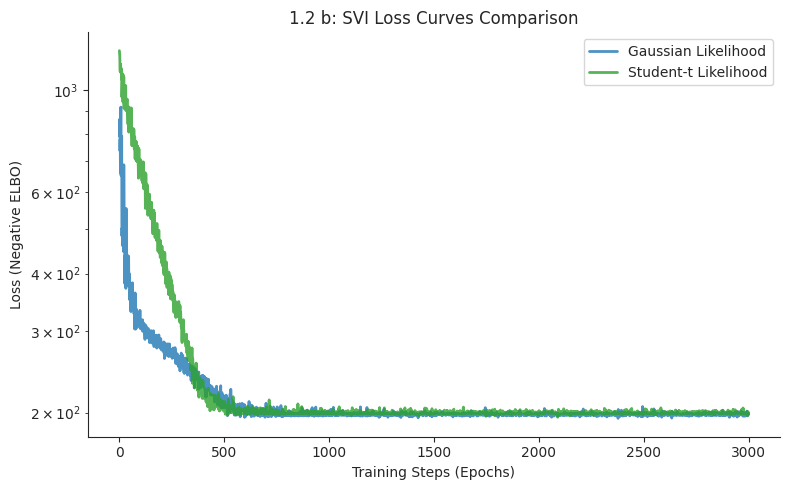

In [23]:
# 1.2.b: Plot the loss curve and compare to Gaussian baseline
plt.figure(figsize=(8, 5))

plt.plot(losses_diag, label='Gaussian Likelihood', linewidth=2, alpha=0.8)
plt.plot(losses_student, label='Student-t Likelihood', linewidth=2, alpha=0.8, color='tab:green')

plt.title('1.2 b: SVI Loss Curves Comparison')
plt.xlabel('Training Steps (Epochs)')
plt.ylabel('Loss (Negative ELBO)')
plt.yscale('log')
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

##1.2c Plot posterior histograms for s under (i) Gaussian likelihood and (ii) Student-t likelihood.

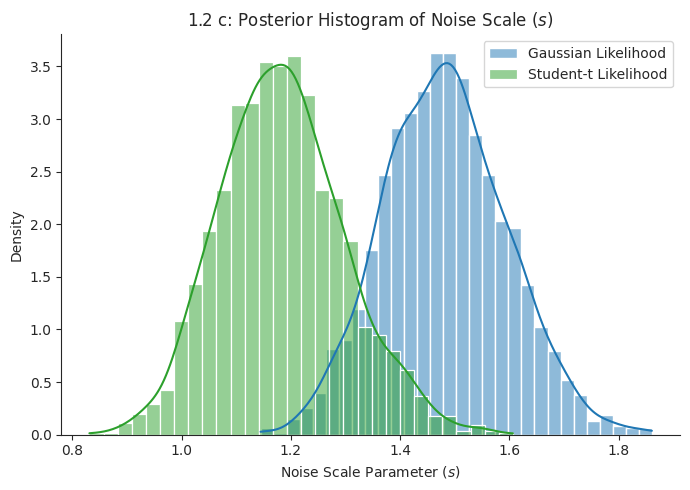

In [24]:
# 1.2 c: Plot posterior histograms for s_eps
key, k_s_gauss, k_s_stud = random.split(key, 3)

# Resample posterior draws of s_eps for the Gaussian and Student-t models
samps_gauss_clean = sample_posterior(poly_model, svi_diag, state_diag, k_s_gauss, x_train, sites=["s_eps"])
samps_stud_clean  = sample_posterior(student_t_model, svi_student, state_student, k_s_stud, x_train, sites=["s_eps"])

# Extract s_eps samples
s_gauss_clean = samps_gauss_clean["s_eps"]
s_stud_clean  = samps_stud_clean["s_eps"]

plt.figure(figsize=(7, 5))

# Histogram + KDE for Gaussian likelihood
sns.histplot(
    s_gauss_clean, color="tab:blue", kde=True, stat="density",
    label="Gaussian Likelihood", alpha=0.5, bins=30
)

# Histogram + KDE for Student-t likelihood
sns.histplot(
    s_stud_clean, color="tab:green", kde=True, stat="density",
    label="Student-t Likelihood", alpha=0.5, bins=30
)

plt.title("1.2 c: Posterior Histogram of Noise Scale ($s$)")
plt.xlabel("Noise Scale Parameter ($s$)")
plt.ylabel("Density")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

##1.2d Outlier experiment

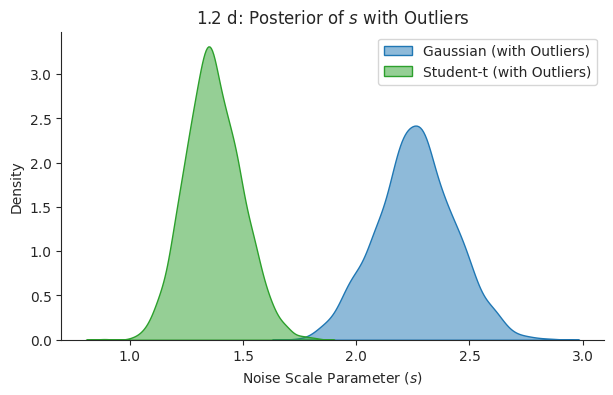

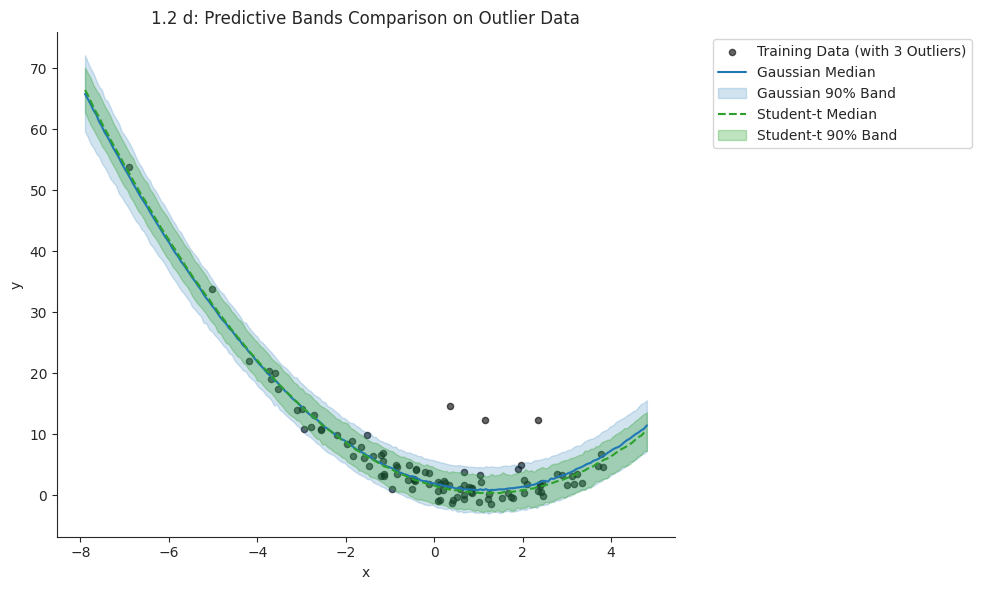

In [12]:
# 1.2 d: Outlier experiment (data + retrain)

# Inject a few large outliers
np.random.seed(42)
outlier_idx = np.random.choice(len(y_train), 3, replace=False)
y_train_outlier = np.array(y_train)
y_train_outlier[outlier_idx] += 12.0
y_train_outlier = jnp.array(y_train_outlier)

# Gaussian model
guide_gauss_out = AutoDiagonalNormal(poly_model)
key, k_train_gauss_out = random.split(key)
svi_gauss_out, state_gauss_out, _ = run_svi(
    poly_model, guide_gauss_out, k_train_gauss_out, x_train, y_train_outlier, lr=0.01, steps=3000
)

# Student-t model
guide_stud_out = AutoDiagonalNormal(student_t_model)
key, k_train_stud_out = random.split(key)
svi_stud_out, state_stud_out, _ = run_svi(
    student_t_model, guide_stud_out, k_train_stud_out, x_train, y_train_outlier, lr=0.01, steps=3000
)

# posterior of s_eps
key, k_s_gauss_out, k_s_stud_out = random.split(key, 3)
s_gauss_out = sample_posterior(poly_model, svi_gauss_out, state_gauss_out, k_s_gauss_out, x_train, sites=["s_eps"])["s_eps"]
s_stud_out  = sample_posterior(student_t_model, svi_stud_out, state_stud_out, k_s_stud_out, x_train, sites=["s_eps"])["s_eps"]

plt.figure(figsize=(7, 4))
sns.kdeplot(s_gauss_out, color="tab:blue", fill=True, label="Gaussian (with Outliers)", alpha=0.5)
sns.kdeplot(s_stud_out,  color="tab:green", fill=True, label="Student-t (with Outliers)", alpha=0.5)
plt.title("1.2 d: Posterior of $s$ with Outliers")
plt.xlabel("Noise Scale Parameter ($s$)")
plt.legend()
sns.despine()
plt.show()

# predictive bands
key, k_p_gauss, k_p_stud = random.split(key, 3)
y_pred_gauss_out = sample_posterior(poly_model, svi_gauss_out, state_gauss_out, k_p_gauss, x_test, sites=["y"])["y"]
y_pred_stud_out  = sample_posterior(student_t_model, svi_stud_out, state_stud_out, k_p_stud, x_test, sites=["y"])["y"]

lo_g, med_g, hi_g = predictive_band_from_mu(y_pred_gauss_out)
lo_s, med_s, hi_s = predictive_band_from_mu(y_pred_stud_out)

plt.figure(figsize=(10, 6))
plt.scatter(x_train, y_train_outlier, color="black", s=20, alpha=0.6, label="Training Data (with 3 Outliers)")

plt.plot(x_test, med_g, color="tab:blue", label="Gaussian Median")
plt.fill_between(x_test, lo_g, hi_g, color="tab:blue", alpha=0.2, label="Gaussian 90% Band")

plt.plot(x_test, med_s, color="tab:green", linestyle="--", label="Student-t Median")
plt.fill_between(x_test, lo_s, hi_s, color="tab:green", alpha=0.3, label="Student-t 90% Band")

plt.title("1.2 d: Predictive Bands Comparison on Outlier Data")
plt.xlabel("x")
plt.ylabel("y")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
sns.despine()
plt.tight_layout()
plt.show()

## 1.2e Compute the fraction of training points covered by the 90% predictive interval for both likelihood choices (with and without outliers).

In [13]:
# 1.2.e: Compute 90% interval coverage fraction
key, k1, k2, k3, k4 = random.split(key, 5)

y_pred_gauss_clean = sample_posterior(poly_model, svi_diag, state_diag, k1, x_train, sites=["y"])["y"]
y_pred_stud_clean = sample_posterior(student_t_model, svi_student, state_student, k2, x_train, sites=["y"])["y"]

y_pred_gauss_out_train = sample_posterior(poly_model, svi_gauss_out, state_gauss_out, k3, x_train, sites=["y"])["y"]
y_pred_stud_out_train = sample_posterior(student_t_model, svi_stud_out, state_stud_out, k4, x_train, sites=["y"])["y"]

# Calculate coverage
cov_gauss_clean = coverage_from_mu(y_pred_gauss_clean, y_train, alpha=0.10)
cov_stud_clean = coverage_from_mu(y_pred_stud_clean, y_train, alpha=0.10)
cov_gauss_out = coverage_from_mu(y_pred_gauss_out_train, y_train_outlier, alpha=0.10)
cov_stud_out = coverage_from_mu(y_pred_stud_out_train, y_train_outlier, alpha=0.10)

print("=== 90% Predictive Interval Coverage Fraction ===")
print(f"Clean Data - Gaussian Likelihood : {cov_gauss_clean:.2%}")
print(f"Clean Data - Student-t Likelihood: {cov_stud_clean:.2%}")
print(f"Outlier Data - Gaussian Likelihood : {cov_gauss_out:.2%}")
print(f"Outlier Data - Student-t Likelihood: {cov_stud_out:.2%}")

=== 90% Predictive Interval Coverage Fraction ===
Clean Data - Gaussian Likelihood : 93.00%
Clean Data - Student-t Likelihood: 93.00%
Outlier Data - Gaussian Likelihood : 96.00%
Outlier Data - Student-t Likelihood: 90.00%


#1.3  Heteroscedastic noise and learned noise curve

Noise model:
$ s(x)=\exp(ax+c),\quad y_i\sim\mathcal N(wx_i+b,\ s(x_i)).$

**Tasks**
1. Implement `hetero_model` with sites `w,b,a,c` and train with an autoguide.
2. Plot the loss curve and report posterior mean/std for `w,b,a,c`.
3. Using posterior samples, compute and plot median and 90% band for the function `s(x)` on a dense grid.
4. Compare predictive bands to homoscedastic baseline.
5. Discuss one identifiability/optimization challenge.


##1.3a Implement `hetero_model` with sites `w,b,a,c` and train with an autoguide.

In [14]:
np.random.seed(123)
x_train_lin = np.random.uniform(-3, 3, 150)
x_train_lin.sort()
s_true = np.exp(0.4 * x_train_lin - 0.5)
y_train_lin = 2.0 * x_train_lin + 1.0 + np.random.normal(0, s_true)

x_train_lin = jnp.array(x_train_lin)
y_train_lin = jnp.array(y_train_lin)
x_test_lin = jnp.linspace(-4, 4, 200)

# 1.3 a: Implement the heteroscedastic model
def heteroscedastic_model(x, y=None):
    w = numpyro.sample("w", dist.Normal(0.0, 10.0))
    b = numpyro.sample("b", dist.Normal(0.0, 10.0))
    a = numpyro.sample("a", dist.Normal(0.0, 2.0))
    c = numpyro.sample("c", dist.Normal(0.0, 2.0))
    mu = w * x + b
    s_x = jnp.exp(a * x + c)

    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("y", dist.Normal(mu, s_x), obs=y)

##1.3b Plot the loss curve and report posterior mean/std for `w,b,a,c`.

Training Heteroscedastic Model...


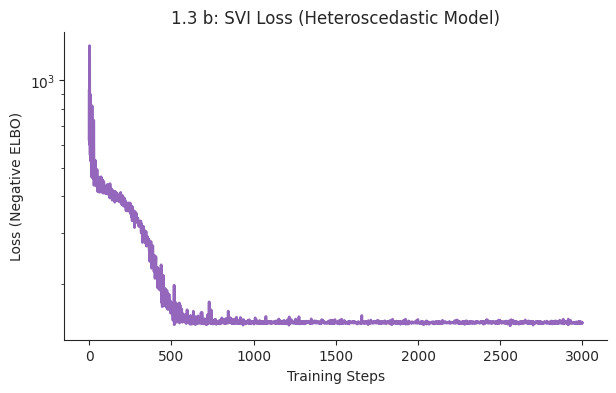

=== 1.3 b: Posterior Summaries (w, b, a, c) ===
 w: Mean =  1.974, Std = 0.028, 95% CI = [ 1.920,  2.028]
 b: Mean =  0.945, Std = 0.055, 95% CI = [ 0.842,  1.052]
 a: Mean =  0.426, Std = 0.038, 95% CI = [ 0.352,  0.500]
 c: Mean = -0.555, Std = 0.058, 95% CI = [-0.666, -0.441]


In [15]:
# 1.3 b: Train with an autoguide and plot loss
guide_het = AutoMultivariateNormal(heteroscedastic_model) # MVN
key, key_het = random.split(key)

svi_het, state_het, losses_het = run_svi(
    heteroscedastic_model, guide_het, key_het, x_train_lin, y_train_lin, lr=0.01, steps=3000
)

# Plot training loss (negative ELBO)
plt.figure(figsize=(7, 4))
plt.plot(losses_het, color='tab:purple', linewidth=2)
plt.title('1.3 b: SVI Loss (Heteroscedastic Model)')
plt.xlabel('Training Steps')
plt.ylabel('Loss (Negative ELBO)')
plt.yscale('log')
sns.despine()
plt.show()

# Posterior summaries for key parameters
key, key_samps_het = random.split(key)
samples_het = sample_posterior(heteroscedastic_model, svi_het, state_het, key_samps_het, x_train_lin, sites=["w", "b", "a", "c"])

print("=== 1.3 b: Posterior Summaries (w, b, a, c) ===")
for param in ["w", "b", "a", "c"]:
    mean, std, lo, hi = summary_stats(samples_het[param])
    print(f"{param:>2}: Mean = {mean:>6.3f}, Std = {std:>5.3f}, 95% CI = [{lo:>6.3f}, {hi:>6.3f}]")

##1.3c Using posterior samples, compute and plot median and 90% band for the function `s(x)` on a dense grid.

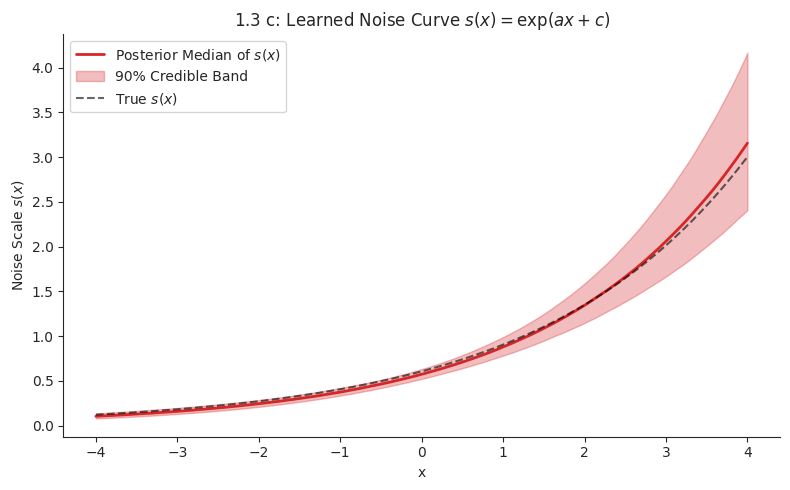

In [16]:
# 1.3 c: Compute s(x*) on a dense grid and plot
s_x_samples = jnp.exp(samples_het["a"][:, None] * x_test_lin + samples_het["c"][:, None])

# Compute quantile bands (5%, 50%, 95%)
lo_s, med_s, hi_s = predictive_band_from_mu(s_x_samples, q=(0.05, 0.5, 0.95))

plt.figure(figsize=(8, 5))
plt.plot(x_test_lin, med_s, color="tab:red", label="Posterior Median of $s(x)$", linewidth=2)
plt.fill_between(x_test_lin, lo_s, hi_s, color="tab:red", alpha=0.3, label="90% Credible Band")

# True noise curve used for data generation
s_true_grid = np.exp(0.4 * x_test_lin - 0.5)
plt.plot(x_test_lin, s_true_grid, color="k", linestyle="--", alpha=0.6, label="True $s(x)$")

plt.title("1.3 c: Learned Noise Curve $s(x) = \\exp(ax + c)$")
plt.xlabel("x")
plt.ylabel("Noise Scale $s(x)$")
plt.legend()
sns.despine()
plt.tight_layout()
plt.show()

##1.3 d. Compare predictive bands to homoscedastic baseline.

Training Homoscedastic Baseline Model...


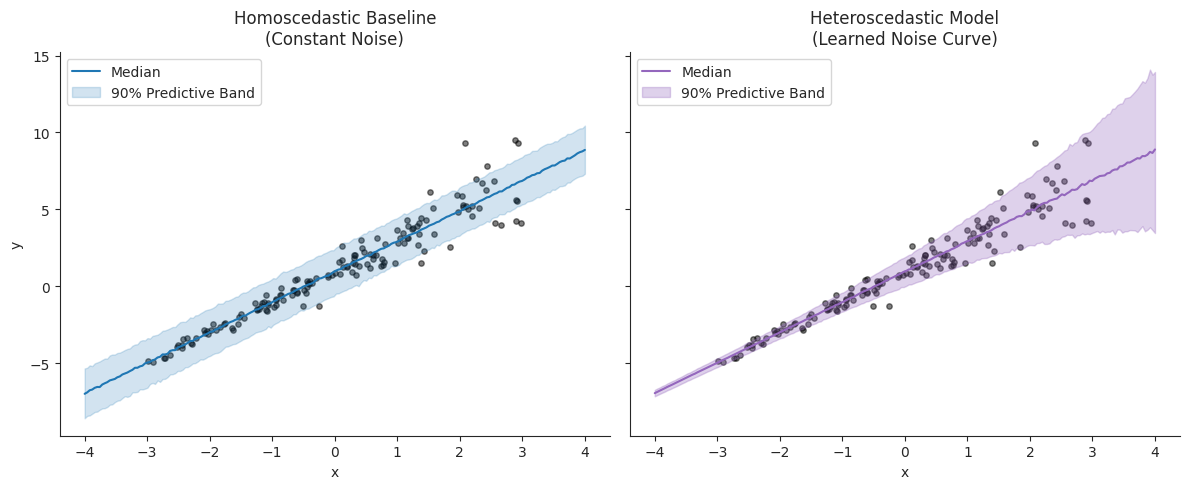

In [17]:
# 1.3 d: Compare predictive bands (Heteroscedastic vs Homoscedastic)

def homoscedastic_baseline(x, y=None):
    w = numpyro.sample("w", dist.Normal(0.0, 10.0))
    b = numpyro.sample("b", dist.Normal(0.0, 10.0))
    s_eps = numpyro.sample("s_eps", dist.HalfCauchy(10.0))  # constant noise scale
    mu = w * x + b
    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("y", dist.Normal(mu, s_eps), obs=y)

print("Training Homoscedastic Baseline Model...")
guide_homo = AutoMultivariateNormal(homoscedastic_baseline)
key, k_homo = random.split(key)
svi_homo, state_homo, _ = run_svi(
    homoscedastic_baseline, guide_homo, k_homo, x_train_lin, y_train_lin, lr=0.01, steps=3000
)

# Posterior predictive samples of y for both models
key, k_pred_het, k_pred_homo = random.split(key, 3)
y_pred_het = sample_posterior(heteroscedastic_model, svi_het, state_het, k_pred_het, x_test_lin, sites=["y"])["y"]
y_pred_homo = sample_posterior(homoscedastic_baseline, svi_homo, state_homo, k_pred_homo, x_test_lin, sites=["y"])["y"]

# 90% predictive bands
lo_het, med_het, hi_het = predictive_band_from_mu(y_pred_het)
lo_homo, med_homo, hi_homo = predictive_band_from_mu(y_pred_homo)

# Side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

axes[0].scatter(x_train_lin, y_train_lin, color="k", s=15, alpha=0.5)
axes[0].plot(x_test_lin, med_homo, color="tab:blue", label="Median")
axes[0].fill_between(x_test_lin, lo_homo, hi_homo, color="tab:blue", alpha=0.2, label="90% Predictive Band")
axes[0].set_title("Homoscedastic Baseline\n(Constant Noise)")
axes[0].set_xlabel("x")
axes[0].set_ylabel("y")
axes[0].legend(loc="upper left")

axes[1].scatter(x_train_lin, y_train_lin, color="k", s=15, alpha=0.5)
axes[1].plot(x_test_lin, med_het, color="tab:purple", label="Median")
axes[1].fill_between(x_test_lin, lo_het, hi_het, color="tab:purple", alpha=0.3, label="90% Predictive Band")
axes[1].set_title("Heteroscedastic Model\n(Learned Noise Curve)")
axes[1].set_xlabel("x")
axes[1].legend(loc="upper left")

sns.despine()
plt.tight_layout()
plt.show()

#1.4 Hierarchical prior on w and b

Model:
$\alpha\sim\mathcal N(0,10^2),\ 	au\sim\mathrm{HalfCauchy}(5),\ w\sim\mathcal N(\alpha,	au),\ b\sim\mathcal N(\alpha,	au).$

**Tasks**
1. Implement the hierarchical model with sites `alpha, tau, w, b, s_eps`.
2. Train SVI (recommended: `AutoMultivariateNormal`) and plot the loss curve.
3. Posterior samples: report mean/std/95% CI for `alpha,tau,w,b,s_eps`.
4. Plot marginals for `alpha` and `tau` and interpret shrinkage.
5. Compare posterior of `(w,b)` to the non-hierarchical baseline.

##1.4a Implement the hierarchical model with sites `alpha, tau, w, b, s_eps`.

In [18]:
def hierarchical_model(x, y=None):
    alpha = numpyro.sample("alpha", dist.Normal(0.0, 10.0))
    tau = numpyro.sample("tau", dist.HalfCauchy(5.0))
    w = numpyro.sample("w", dist.Normal(alpha, tau))
    b = numpyro.sample("b", dist.Normal(alpha, tau))
    s_eps = numpyro.sample("s_eps", dist.HalfCauchy(10.0))
    mu = w * x + b

    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("y", dist.Normal(mu, s_eps), obs=y)

##1.4b Train SVI (recommended: `AutoMultivariateNormal`) and plot the loss curve.

Training Hierarchical Model...


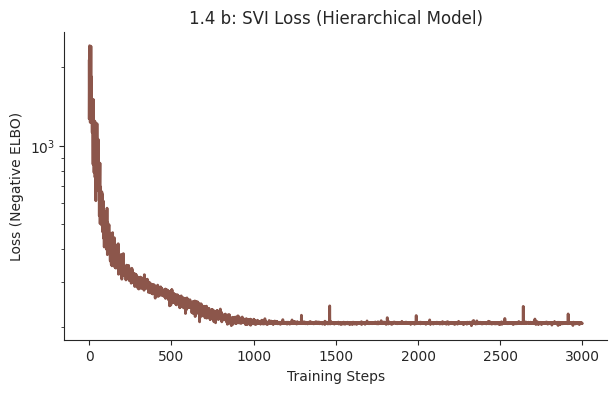

In [19]:
# 1.4 b: Train SVI and plot loss
guide_hier = AutoMultivariateNormal(hierarchical_model)
key, key_hier = random.split(key)

svi_hier, state_hier, losses_hier = run_svi(
    hierarchical_model, guide_hier, key_hier, x_train_lin, y_train_lin, lr=0.01, steps=3000
)

plt.figure(figsize=(7, 4))
plt.plot(losses_hier, color='tab:brown', linewidth=2)
plt.title('1.4 b: SVI Loss (Hierarchical Model)')
plt.xlabel('Training Steps')
plt.ylabel('Loss (Negative ELBO)')
plt.yscale('log')
sns.despine()
plt.show()

##1.4c Posterior samples: report mean/std/95% CI for `alpha,tau,w,b,s_eps`.

In [20]:
# 1.4 c: Draw posterior samples and report summaries
key, key_samps_hier = random.split(key)
sites_hier = ["alpha", "tau", "w", "b", "s_eps"]
samples_hier = sample_posterior(hierarchical_model, svi_hier, state_hier, key_samps_hier, x_train_lin, sites=sites_hier)

print("=== 1.4 c: Posterior Summaries (Hierarchical) ===")
for param in sites_hier:
    mean, std, lo, hi = summary_stats(samples_hier[param])
    print(f"{param:>5}: Mean = {mean:>6.3f}, Std = {std:>5.3f}, 95% CI = [{lo:>6.3f}, {hi:>6.3f}]")

=== 1.4 c: Posterior Summaries (Hierarchical) ===
alpha: Mean =  1.376, Std = 0.923, 95% CI = [-0.461,  3.109]
  tau: Mean =  1.974, Std = 1.131, 95% CI = [ 0.604,  4.990]
    w: Mean =  2.008, Std = 0.052, 95% CI = [ 1.907,  2.111]
    b: Mean =  0.966, Std = 0.073, 95% CI = [ 0.821,  1.107]
s_eps: Mean =  0.889, Std = 0.054, 95% CI = [ 0.787,  0.992]


##1.4d Plot marginals for `alpha` and `tau` and interpret shrinkage.

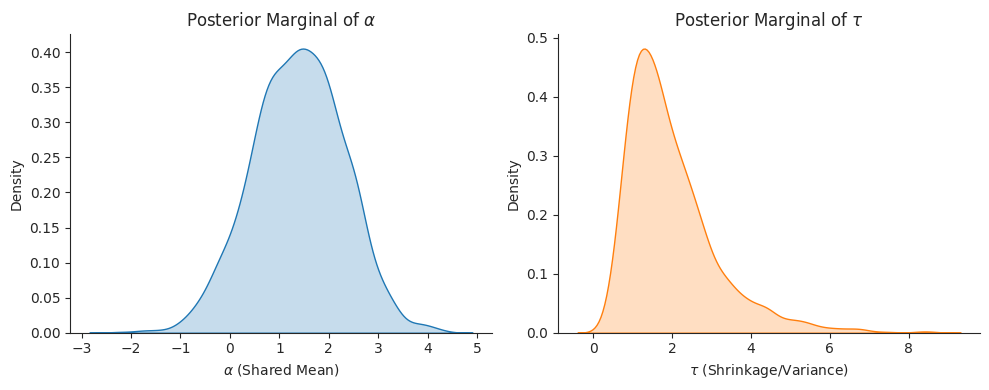

In [21]:
# 1.4 d: Plot marginals for alpha and tau
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

sns.kdeplot(samples_hier["alpha"], ax=axes[0], fill=True, color="tab:blue")
axes[0].set_title('Posterior Marginal of $\\alpha$')
axes[0].set_xlabel('$\\alpha$ (Shared Mean)')

sns.kdeplot(samples_hier["tau"], ax=axes[1], fill=True, color="tab:orange")
axes[1].set_title('Posterior Marginal of $\\tau$')
axes[1].set_xlabel('$\\tau$ (Shrinkage/Variance)')

sns.despine()
plt.tight_layout()
plt.show()

##1.4e. Compare posterior of `(w,b)` to the non-hierarchical baseline.

Training Non-hierarchical Baseline for comparison...


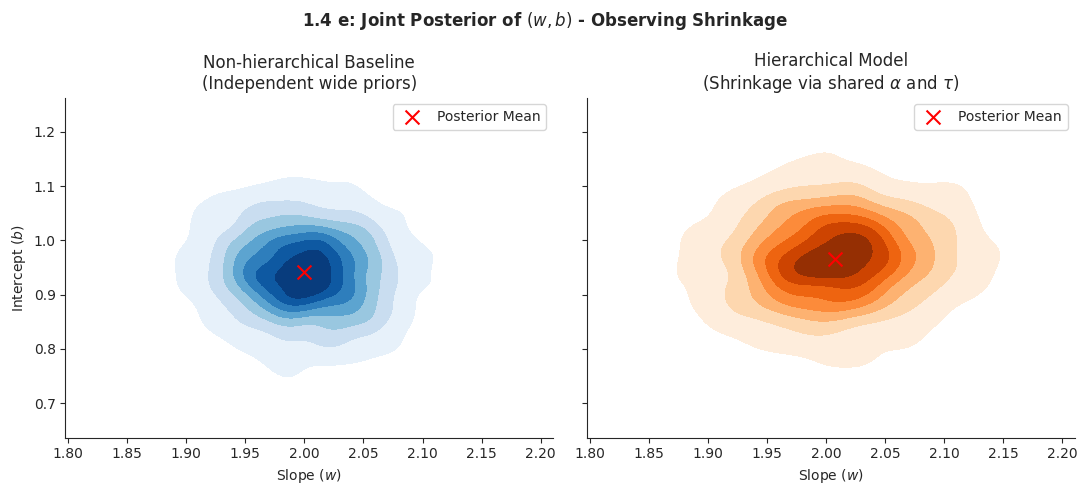

In [22]:
# 1.4 e: Compare posterior of (w, b) and visualize shrinkage
def linear_baseline(x, y=None):
    w = numpyro.sample("w", dist.Normal(0.0, 10.0))
    b = numpyro.sample("b", dist.Normal(0.0, 10.0))
    s_eps = numpyro.sample("s_eps", dist.HalfCauchy(10.0))
    mu = w * x + b
    with numpyro.plate("data", x.shape[0]):
        numpyro.sample("y", dist.Normal(mu, s_eps), obs=y)

print("Training Non-hierarchical Baseline for comparison...")
guide_base = AutoMultivariateNormal(linear_baseline)
key, k_base = random.split(key)
svi_base, state_base, _ = run_svi(
    linear_baseline, guide_base, k_base, x_train_lin, y_train_lin, lr=0.01, steps=3000
)

# Posterior samples for (w, b) under the baseline model
key, k_samps_base = random.split(key)
samples_base = sample_posterior(linear_baseline, svi_base, state_base, k_samps_base, x_train_lin, sites=["w", "b"])
w_base, b_base = samples_base["w"], samples_base["b"]

# Posterior samples for (w, b) under the hierarchical model
w_hier, b_hier = samples_hier["w"], samples_hier["b"]

# Compare joint posteriors via 2D KDE contours
fig, axes = plt.subplots(1, 2, figsize=(11, 5), sharex=True, sharey=True)

sns.kdeplot(x=w_base, y=b_base, ax=axes[0], cmap="Blues", fill=True, levels=8, thresh=0.05)
axes[0].scatter(w_base.mean(), b_base.mean(), color="red", marker="x", s=100, label="Posterior Mean")
axes[0].set_title("Non-hierarchical Baseline\n(Independent wide priors)")
axes[0].set_xlabel("Slope ($w$)")
axes[0].set_ylabel("Intercept ($b$)")
axes[0].legend()

sns.kdeplot(x=w_hier, y=b_hier, ax=axes[1], cmap="Oranges", fill=True, levels=8, thresh=0.05)
axes[1].scatter(w_hier.mean(), b_hier.mean(), color="red", marker="x", s=100, label="Posterior Mean")
axes[1].set_title("Hierarchical Model\n(Shrinkage via shared $\\alpha$ and $\\tau$)")
axes[1].set_xlabel("Slope ($w$)")
axes[1].set_ylabel("Intercept ($b$)")
axes[1].legend()

plt.suptitle("1.4 e: Joint Posterior of $(w, b)$ - Observing Shrinkage", fontweight="bold")
sns.despine()
plt.tight_layout()
plt.show()